  symbol        date       open       high        low      close    volume  \
0   GOOG  2018-01-02  52.417000  53.347000  52.261501  53.250000  24752000   
1   GOOG  2018-01-03  53.215500  54.314499  53.160500  54.124001  28604000   
2   GOOG  2018-01-04  54.400002  54.678501  54.200100  54.320000  20092000   
3   GOOG  2018-01-05  54.700001  55.212502  54.599998  55.111500  25582000   
4   GOOG  2018-01-08  55.111500  55.563499  55.081001  55.347000  20952000   

    adjclose  dividends  splits  
0  53.059353        0.0     0.0  
1  53.930225        0.0     0.0  
2  54.125519        0.0     0.0  
3  54.914188        0.0     0.0  
4  55.148846        0.0     0.0  
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'adjclose',
       'dividends', 'splits'],
      dtype='object')


C:\Users\VEDANG\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0218
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.1948e-04
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.9710e-04
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.6772e-04
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.0795e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


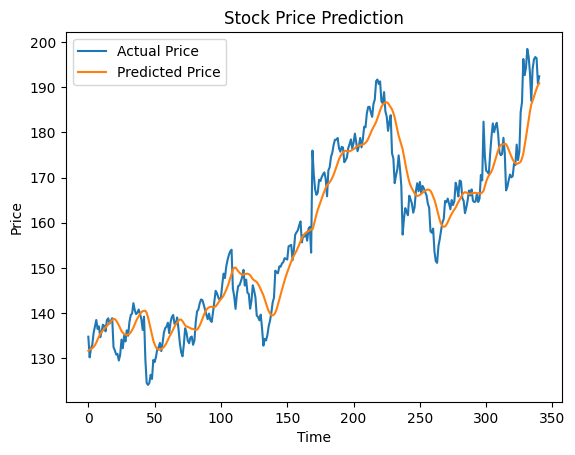

RMSE: 5.625773419078068
MAE: 4.256443415219483


In [4]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Step 2: Load dataset
df = pd.read_csv("Google_Stock_Price.csv")

print(df.head())
print(df.columns)   # optional (to verify column names)

# Step 3: Use 'open' column (FIXED)
prices = df['open'].values.reshape(-1,1)

# Step 4: Normalize
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)

# Step 5: Create sequences
X, y = [], []
for i in range(60, len(prices)):
    X.append(prices[i-60:i])
    y.append(prices[i])

X, y = np.array(X), np.array(y)

# Step 6: Train-Test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 7: Model (LSTM)
model = Sequential([
    LSTM(50, input_shape=(X.shape[1], 1)),
    Dense(1)
])

# Step 8: Compile
model.compile(optimizer='adam', loss='mse')

# Step 9: Train
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

# Step 10: Predict
predicted = model.predict(X_test)

# Step 11: Inverse scaling
predicted = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test)

# Step 12: Best Graph (Actual vs Predicted)
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

# Step 13: Evaluation
rmse = np.sqrt(mean_squared_error(y_test_actual, predicted))
mae = mean_absolute_error(y_test_actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)